In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import random
from PIL import Image

In [2]:
DATA_CSV = "Alzheimer_Dataset_Details.csv"
IMG_BASE = "Alzheimer_Split/Alzheimer_Split"

df = pd.read_csv(DATA_CSV)
print(f"Shape: {df.shape[0]} images, {df.shape[1]} columns\n")
print("Missing values:", df.isna().sum().sum())
print("Duplicate filenames:", df["Filename"].duplicated().sum())
print("Duplicate full rows:", df.duplicated().sum(), "\n")
df.info()
df.head()

Shape: 6336 images, 11 columns

Missing values: 0
Duplicate filenames: 0
Duplicate full rows: 0 

<class 'pandas.DataFrame'>
RangeIndex: 6336 entries, 0 to 6335
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Split           6336 non-null   str    
 1   Disease         6336 non-null   str    
 2   Filename        6336 non-null   str    
 3   Extension       6336 non-null   str    
 4   Width           6336 non-null   int64  
 5   Height          6336 non-null   int64  
 6   Channels        6336 non-null   int64  
 7   Color Mode      6336 non-null   str    
 8   File Size (KB)  6336 non-null   float64
 9   File Size (MB)  6336 non-null   float64
 10  Full Path       6336 non-null   str    
dtypes: float64(2), int64(3), str(6)
memory usage: 544.6 KB


,Split,Disease,Filename,Extension,Width,Height,Channels,Color Mode,File Size (KB),File Size (MB),Full Path
0,train,Mild_Demented,mild_10.jpg,.jpg,128,128,1,L,4.08,0.0040,C:\Users\mohib\Desktop\Alzheimer_Split\train\M...
1,train,Mild_Demented,mild_100.jpg,.jpg,128,128,1,L,3.95,0.0039,C:\Users\mohib\Desktop\Alzheimer_Split\train\M...
2,train,Mild_Demented,mild_102.jpg,.jpg,128,128,1,L,3.92,0.0038,C:\Users\mohib\Desktop\Alzheimer_Split\train\M...
3,train,Mild_Demented,mild_103.jpg,.jpg,128,128,1,L,3.95,0.0039,C:\Users\mohib\Desktop\Alzheimer_Split\train\M...
4,train,Mild_Demented,mild_106.jpg,.jpg,128,128,1,L,4.02,0.0039,C:\Users\mohib\Desktop\Alzheimer_Split\train\M...


Overall class distribution:
 Disease
Non_Demented          3200
Very_Mild_Demented    2240
Mild_Demented          896 

Per split:
 Disease  Mild_Demented  Non_Demented  Very_Mild_Demented
Split                                                   
test               135           480                 336
train              627          2240                1568
val                134           480                 336 

Relative class weight (train, vs Non_Demented):
Disease
Mild_Demented         0.28
Non_Demented          1.00
Very_Mild_Demented    0.70


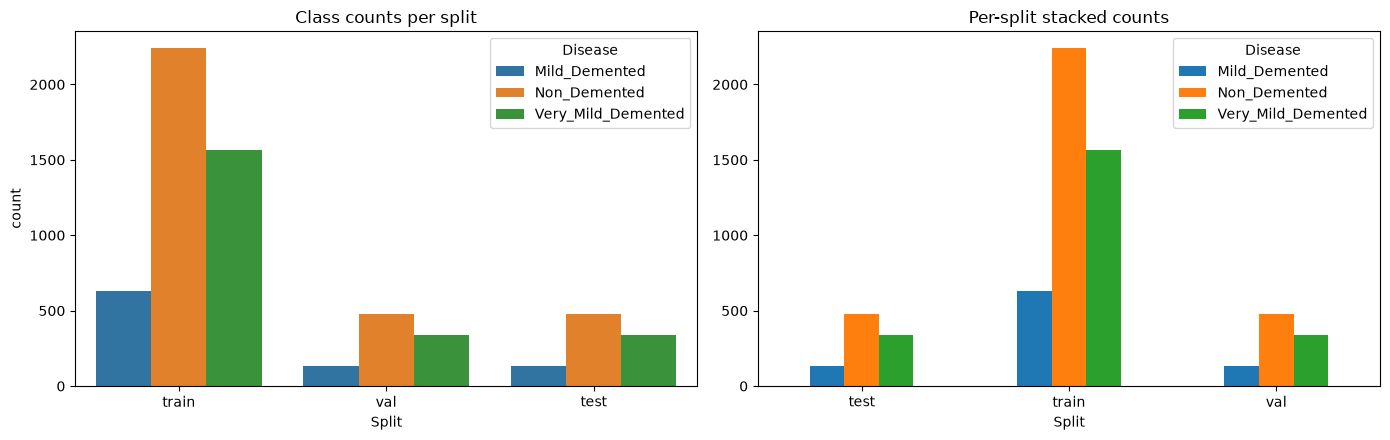

In [3]:
# Class balance across the whole dataset and per split
print("Overall class distribution:\n", df["Disease"].value_counts().to_string(), "\n")
balance = df.groupby(["Split", "Disease"]).size().unstack(fill_value=0)
print("Per split:\n", balance.to_string(), "\n")
print("Relative class weight (train, vs Non_Demented):")
train_cnt = balance.loc["train"]
print((train_cnt / train_cnt["Non_Demented"]).round(3).to_string())

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
sns.countplot(data=df, x="Split", hue="Disease", ax=ax[0])
ax[0].set_title("Class counts per split")
balance.plot(kind="bar", ax=ax[1], rot=0)
ax[1].set_title("Per-split stacked counts")
plt.tight_layout()
plt.show()

Color Mode
L    6336 

Extension
.jpg    6336 

        Width  Height  Channels
count  6336.0  6336.0    6336.0
mean    128.0   128.0       1.0
std       0.0     0.0       0.0
min     128.0   128.0       1.0
25%     128.0   128.0       1.0
50%     128.0   128.0       1.0
75%     128.0   128.0       1.0
max     128.0   128.0       1.0 

File size (KB):
count    6336.000000
mean        4.289575
std         0.243891
min         3.260000
25%         4.120000
50%         4.360000
75%         4.470000
max         4.830000


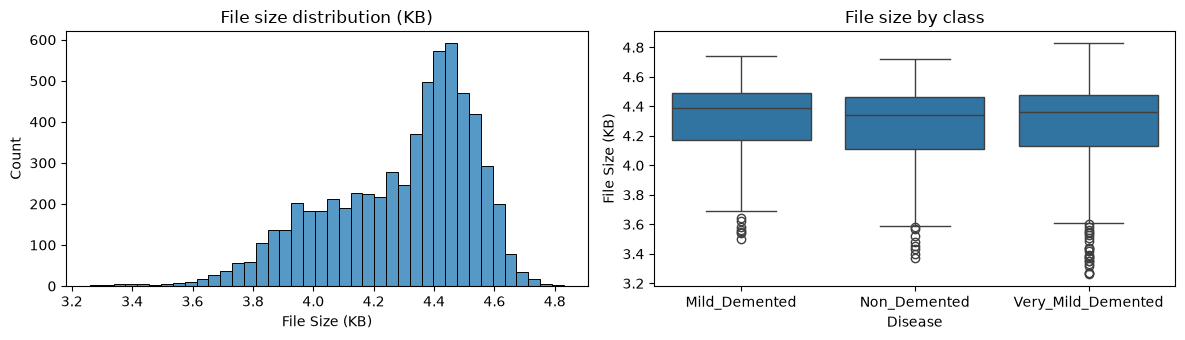

In [4]:
# Image uniformity: dimensions, channels, color mode, format, file size
print(df["Color Mode"].value_counts().to_string(), "\n")
print(df["Extension"].value_counts().to_string(), "\n")
print(df[["Width", "Height", "Channels"]].describe().to_string(), "\n")
print("File size (KB):")
print(df["File Size (KB)"].describe().to_string())

fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
sns.histplot(df["File Size (KB)"], bins=40, ax=ax[0])
ax[0].set_title("File size distribution (KB)")
sns.boxplot(data=df, x="Disease", y="File Size (KB)", ax=ax[1])
ax[1].set_title("File size by class")
plt.tight_layout()
plt.show()

In [5]:
# Data integrity: no filename shared between splits (no leakage), CSV matches disk
from pathlib import Path

dup = df["Filename"].duplicated(keep=False)
leak = df[dup].groupby("Filename")["Split"].nunique()
print("Filenames appearing in >1 split:", int((leak > 1).sum()))

csv_files = set(df["Filename"])
disk_files = set()
for sp in ["train", "val", "test"]:
    for cls in ["Mild_Demented", "Non_Demented", "Very_Mild_Demented"]:
        disk_files |= {p.name for p in Path(IMG_BASE, sp, cls).glob("*.jpg")}
print("In CSV but missing on disk:", len(csv_files - disk_files))
print("On disk but not in CSV:   ", len(disk_files - csv_files))

# Note: the Full Path column points to Windows paths (C:\Users\...) that don't exist here,
# so rebuild paths from Split/Disease/Filename instead.
print("\nSample row:")
print(df[["Split", "Disease", "Filename", "Full Path"]].head(2).to_string(index=False))

Filenames appearing in >1 split: 0
In CSV but missing on disk: 0
On disk but not in CSV:    0

Sample row:
Split       Disease     Filename                                                               Full Path
train Mild_Demented  mild_10.jpg  C:\Users\mohib\Desktop\Alzheimer_Split\train\Mild_Demented\mild_10.jpg
train Mild_Demented mild_100.jpg C:\Users\mohib\Desktop\Alzheimer_Split\train\Mild_Demented\mild_100.jpg


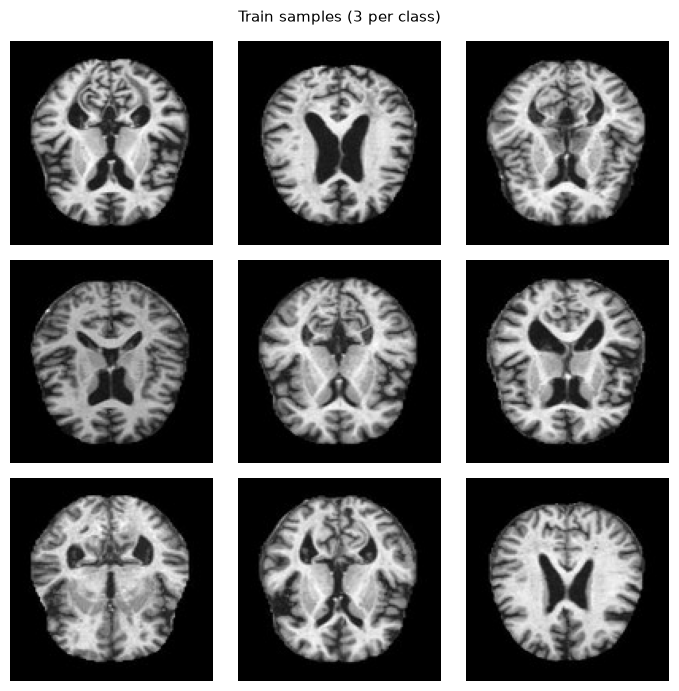

In [6]:
# Visual check: sample images from each class
import random
from PIL import Image

random.seed(42)
fig, axes = plt.subplots(3, 3, figsize=(7, 7))
for row, cls in enumerate(["Mild_Demented", "Non_Demented", "Very_Mild_Demented"]):
    imgs = list(Path(IMG_BASE, "train", cls).glob("*.jpg"))
    for col in range(3):
        img = Image.open(random.choice(imgs)).convert("L")
        axes[row, col].imshow(img, cmap="gray")
        axes[row, col].axis("off")
        if col == 0:
            axes[row, col].set_ylabel(cls, fontsize=9)
plt.suptitle("Train samples (3 per class)", fontsize=11)
plt.tight_layout()
plt.show()

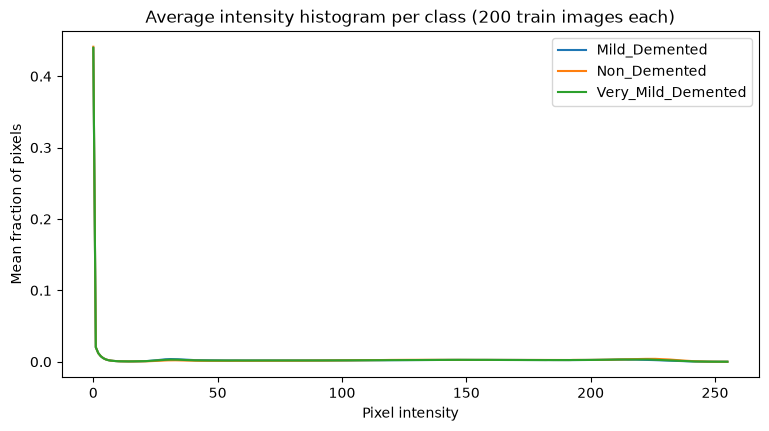

In [7]:
# Pixel intensity comparison between classes (sample 200 train images per class)
from PIL import Image
import numpy as np

fig, ax = plt.subplots(1, 1, figsize=(9, 4.5))
for cls in ["Mild_Demented", "Non_Demented", "Very_Mild_Demented"]:
    imgs = list(Path(IMG_BASE, "train", cls).glob("*.jpg"))
    sample = random.Random(7).sample(imgs, 200)
    hist = np.zeros(256)
    for p in sample:
        hist += np.bincount(np.asarray(Image.open(p).convert("L")).flatten(), minlength=256)
    ax.plot(np.arange(256), hist / len(sample) / (128 * 128), label=cls, lw=1.5)
ax.set_xlabel("Pixel intensity"); ax.set_ylabel("Mean fraction of pixels")
ax.set_title("Average intensity histogram per class (200 train images each)")
ax.legend()
plt.show()